# <b><font color='chocolate'>Практикум</font></b>

### <font color='chocolate'>Задача №1</font>
В файле movies.csv содержится информация о фильмах: название, рейтинг, год выпуска, режиссер, жанр. На основе этих данных создайте датафрейм и постройте цветовую карту для демонстрации распределения рейтингов по годам.

In [4]:
# мпорт бибилиотек
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [14]:
df_movies = pd.read_csv('../data/movies.csv')

df_movies.groupby('Год', as_index=False)['Рейтинг'].mean().sort_values('Рейтинг', ascending=False)
df_movies

,Название,Рейтинг,Год,Режиссер,Жанр
0,Одинокий мужчина,7.6,2009,Том Форд,драма
1,Криминальное чтиво,8.9,1994,Квентин Тарантино,криминал
2,Гладиатор,8.5,2000,Ридли Скотт,исторический
3,Зеленая миля,8.6,1999,Фрэнк Дарабонт,драма
4,Заводной апельсин,8.3,1971,Стэнли Кубрик,фантастика
5,Побег из Шоушенка,9.3,1994,Фрэнк Дарабонт,драма
6,Терминатор,8.1,1984,Джеймс Кэмерон,фантастика
7,Крестный отец,9.2,1972,Фрэнсис Форд Коппола,криминал
8,Крестный отец 2,9.0,1974,Фрэнсис Форд Коппола,криминал
9,Бойцовский клуб,8.8,1999,Дэвид Финчер,драма


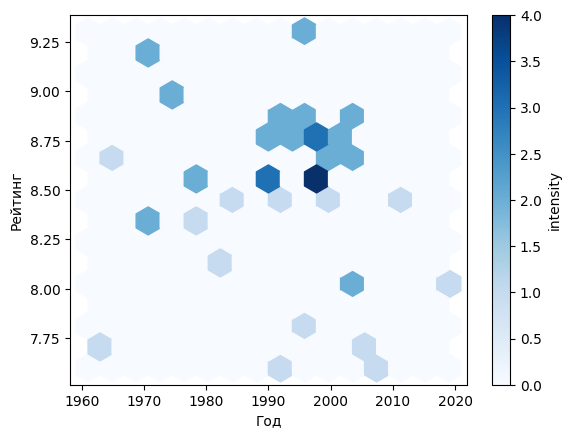

In [8]:
plt.hexbin(df_movies['Год'], df_movies['Рейтинг'], gridsize = 15, cmap = 'Blues')
cb = plt.colorbar()
cb.set_label('intensity')
plt.xlabel("Год")
plt.ylabel("Рейтинг")
plt.show()

### <font color='chocolate'>Задача №2</font>
Для предыдущего файла постройте столбчатую диаграмму, показывающую количество фильмов каждого жанра. Добавьте на этот рисунок два вложенных графика – гистограммы распределения фильмов по годам и по рейтингам.

Жанр
драма                    12
фантастика               11
криминал                  8
фэнтези                   6
исторический              3
комедия                   3
военный                   2
триллер                   2
приключенческий           2
мелодрама                 1
романтическая комедия     1
Name: Название, dtype: int64

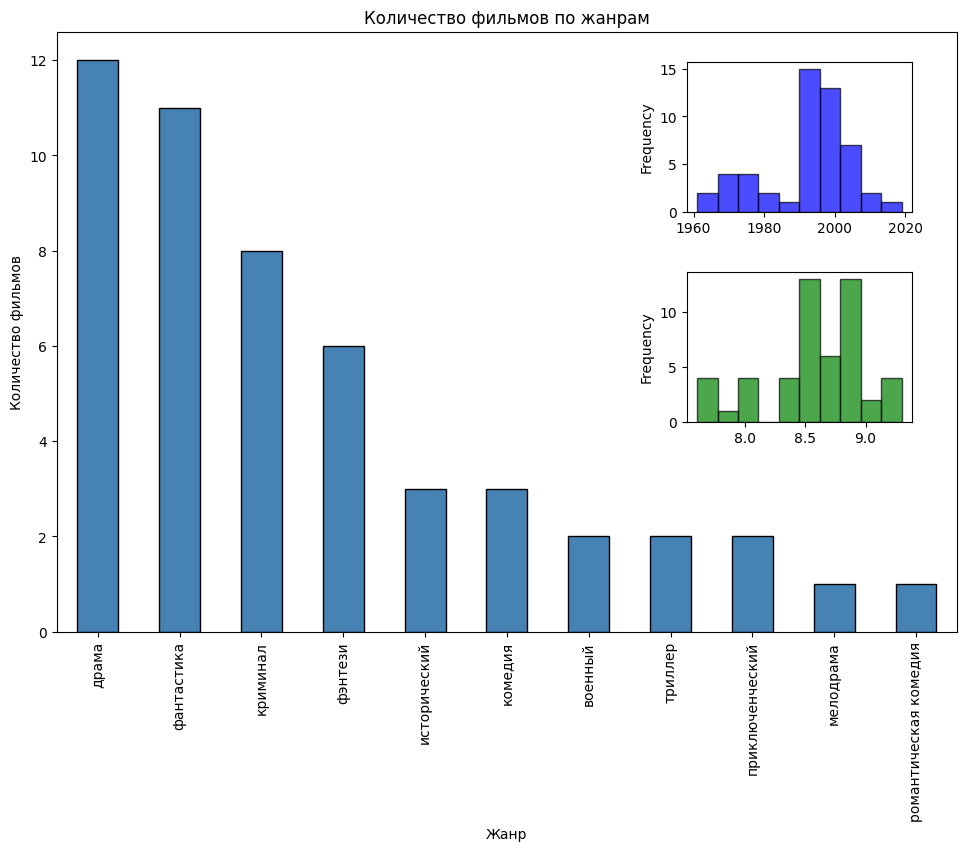

In [43]:
genre_counts = df_movies.groupby('Жанр').count()['Название'].sort_values(ascending=False)
display(genre_counts)
plt.figure(figsize=(9, 6))
plt.axes([0, 0, 1, 1])
genre_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Количество фильмов по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Количество фильмов')
plt.xticks(rotation=90)

plt.axes([0.7, 0.7, 0.25, 0.25])
df_movies['Год'].plot(kind='hist', bins = 10, color='blue', edgecolor='black', alpha=0.7)

plt.axes([0.7, 0.35, 0.25, 0.25])
df_movies['Рейтинг'].plot(kind='hist', bins = 10, color='green', edgecolor='black', alpha=0.7)

plt.show()

### <font color='chocolate'>Задача №3</font>
Прочитайте из файла fruits.csv  данные о продажах фруктов в нескольких магазинах компании. Постройте столбчатую диаграмму количества всех продаж каждый день. Рядом разместите вторую столбчатую диаграмму, демонстрирующую выручку от всех продаж каждый день.

In [69]:
df_fruits = pd.read_csv('../data/fruits.csv')
df_fruits['Выручка'] = df_fruits['Количество'] * df_fruits['Цена'] // 1000
df_fruits

,Фрукт,Магазин,Дата,Количество,Цена,Выручка
0,Яблоки,Фермер,2023-01-01,350,100.0,35.0
1,Апельсины,Фермер,2023-01-01,380,120.0,45.0
2,Манго,Фермер,2023-01-01,120,480.0,57.0
3,Виноград,Фермер,2023-01-01,300,150.0,45.0
4,Лимоны,Фермер,2023-01-01,150,130.0,19.0
...,...,...,...,...,...,...
163,Апельсины,Радуга,2023-07-01,200,110.0,22.0
164,Манго,Радуга,2023-07-01,280,550.0,154.0
165,Виноград,Радуга,2023-07-01,260,220.0,57.0
166,Лимоны,Радуга,2023-07-01,130,150.0,19.0


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '2023-01-01'),
  Text(1, 0, '2023-02-01'),
  Text(2, 0, '2023-03-01'),
  Text(3, 0, '2023-04-01'),
  Text(4, 0, '2023-05-01'),
  Text(5, 0, '2023-06-01'),
  Text(6, 0, '2023-07-01')])

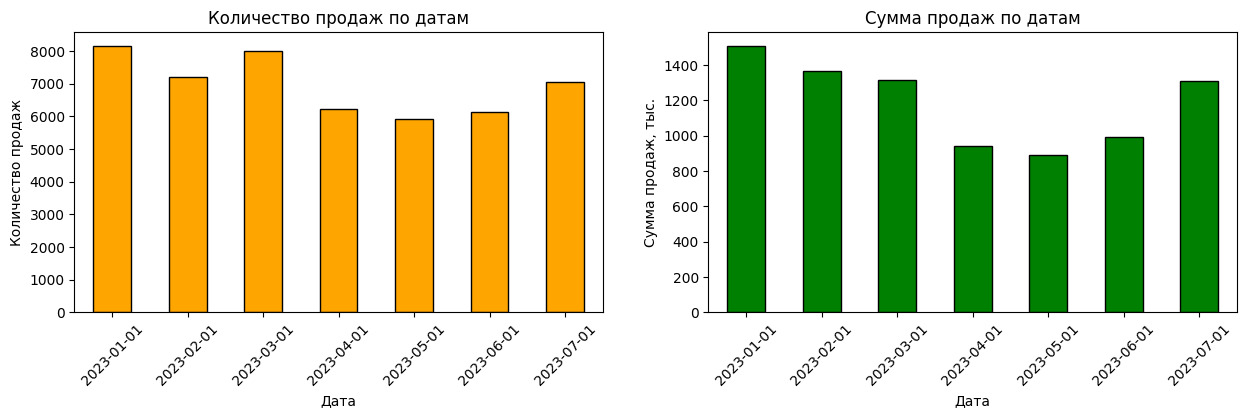

In [79]:
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
df_fruits.groupby('Дата').sum()['Количество'].plot(kind='bar', color='orange', edgecolor='black')
plt.title('Количество продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
df_fruits.groupby('Дата').sum()['Выручка'].plot(kind='bar', color='green', edgecolor='black')
plt.title('Сумма продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж, тыс.')
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '2023-01-01'),
  Text(1, 0, '2023-02-01'),
  Text(2, 0, '2023-03-01'),
  Text(3, 0, '2023-04-01'),
  Text(4, 0, '2023-05-01'),
  Text(5, 0, '2023-06-01'),
  Text(6, 0, '2023-07-01')])

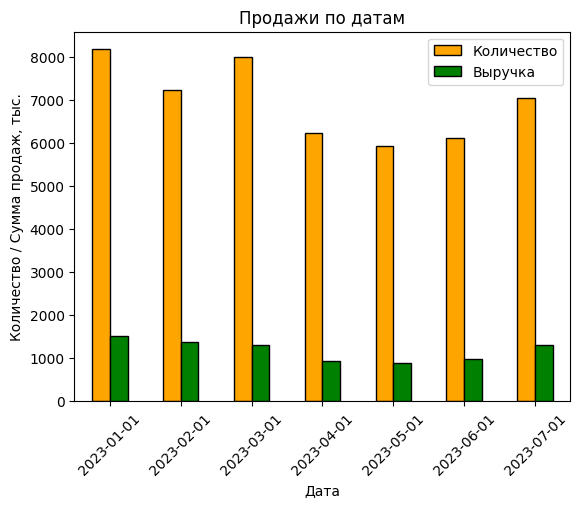

In [84]:
# plt.figure(figsize=(15, 8))
df_fruits.groupby('Дата').sum()[['Количество', 'Выручка']].plot(kind='bar', color=['orange', 'green'], edgecolor='black')
plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество / Сумма продаж, тыс.')
plt.xticks(rotation=45)

### <font color='chocolate'>Задача №4</font>
Разместите обе столбчатые диаграммы из предыдущей задачи на одном графике, с общей осью Х и двумя отдельными осями Y.

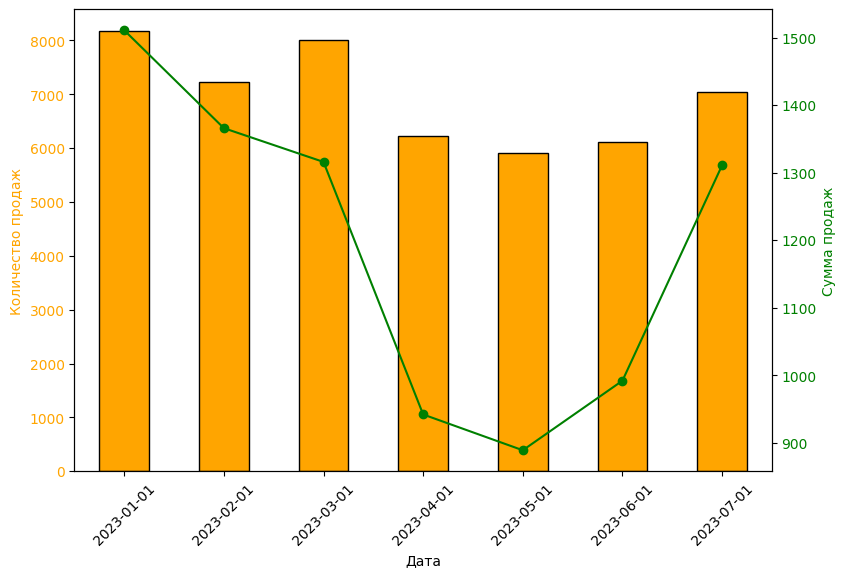

In [90]:
plt.figure(figsize=(9, 6))
# Функция subplot возвращает оси графика и далее мы можем с ними взаимодействовать
ax1 = plt.subplot() # по умолчани 1, 1, 1
df_fruits.groupby('Дата').sum()['Количество'].plot(kind='bar', color='orange', edgecolor='black', ax=ax1, label='Количество продаж')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

ax2 = ax1.twinx()
df_fruits.groupby('Дата').sum()['Выручка'].plot(kind='line', marker='o', color='green', ax=ax2, label='Сумма продаж')
ax2.set_ylabel('Сумма продаж', color='green')
ax2.tick_params(axis='y', labelcolor='green')


plt.show()

In [91]:
df_formula = pd.read_csv('../data/winners_f1_1950_2025_v2.csv')
df_formula

,date,continent,grand_prix,circuit,winner_name,team,time,laps,year
0,1950-05-13,Europe,Great Britain,Silverstone Circuit,NinoВ Farina,Alfa Romeo,02:13:23,70.0,1950
1,1950-05-21,Europe,Monaco,Circuit de Monaco,Juan ManuelВ Fangio,Alfa Romeo,03:13:18,100.0,1950
2,1950-05-30,North America,United States,Indianapolis Motor Speedway,Johnnie Parsons,Kurtis Kraft Offenhauser,02:46:55,138.0,1950
3,1950-06-04,Europe,Switzerland,Circuit Bremgarten,NinoВ Farina,Alfa Romeo,02:02:53,42.0,1950
4,1950-06-18,Europe,Belgium,Circuit de Spa Francorchamps,Juan ManuelВ Fangio,Alfa Romeo,02:47:26,35.0,1950
...,...,...,...,...,...,...,...,...,...
1137,2025-06-15,North America,Canada,Circuit Gilles Villeneuve,GeorgeВ Russell,Mercedes,01:31:52,70.0,2025
1138,2025-06-29,Europe,Austria,Red Bull Ring,LandoВ Norris,McLaren,01:23:47,70.0,2025
1139,2025-07-06,Europe,Great Britain,Silverstone Circuit,LandoВ Norris,McLaren,01:37:15,52.0,2025
1140,2025-07-27,Europe,Belgium,Circuit de Spa Francorchamps,OscarВ Piastri,McLaren,01:25:22,44.0,2025


In [161]:
laps_per_year = df_formula.groupby('year')['laps'].mean()
display(laps_per_year)
top_winners = df_formula['winner_name'].value_counts().head(10)
display(top_winners)
continent_counts = df_formula['continent'].value_counts()
display(continent_counts)
count_team = df_formula[(df_formula['year'] >= 2010) & (df_formula['year'] <= 2025)]['team'].value_counts()
display(count_team)
count_team.groupby(count_team.values).count().sort_values(ascending=False)


year
1950    75.571429
1951    76.888889
1952    81.000000
1953    81.777778
1954    80.222222
          ...    
2021    58.954545
2022    58.818182
2023    60.227273
2024    60.166667
2025    60.214286
Name: laps, Length: 76, dtype: float64

winner_name
LewisВ Hamilton        105
MichaelВ Schumacher     91
MaxВ Verstappen         65
SebastianВ Vettel       53
AlainВ Prost            51
AyrtonВ Senna           41
FernandoВ Alonso        32
NigelВ Mansell          31
JackieВ Stewart         27
JimВ Clark              25
Name: count, dtype: int64

continent
Europe           686
Asia             163
North America    158
South America     72
Oceania           39
Africa            24
Name: count, dtype: int64

team
Mercedes                      121
Ferrari                        38
Red Bull Racing Renault        35
Red Bull Racing Honda RBPT     30
McLaren Mercedes               25
Red Bull Racing RBPT           17
Red Bull Racing Honda          16
McLaren                        11
Red Bull Racing TAG Heuer       9
RBR Renault                     9
Red Bull Racing                 2
Lotus Renault                   2
Williams Renault                1
Alpine Renault                  1
AlphaTauri Honda                1
Racing Point BWT Mercedes       1
Name: count, dtype: int64

1      4
2      2
9      2
11     1
16     1
17     1
25     1
30     1
35     1
38     1
121    1
Name: count, dtype: int64

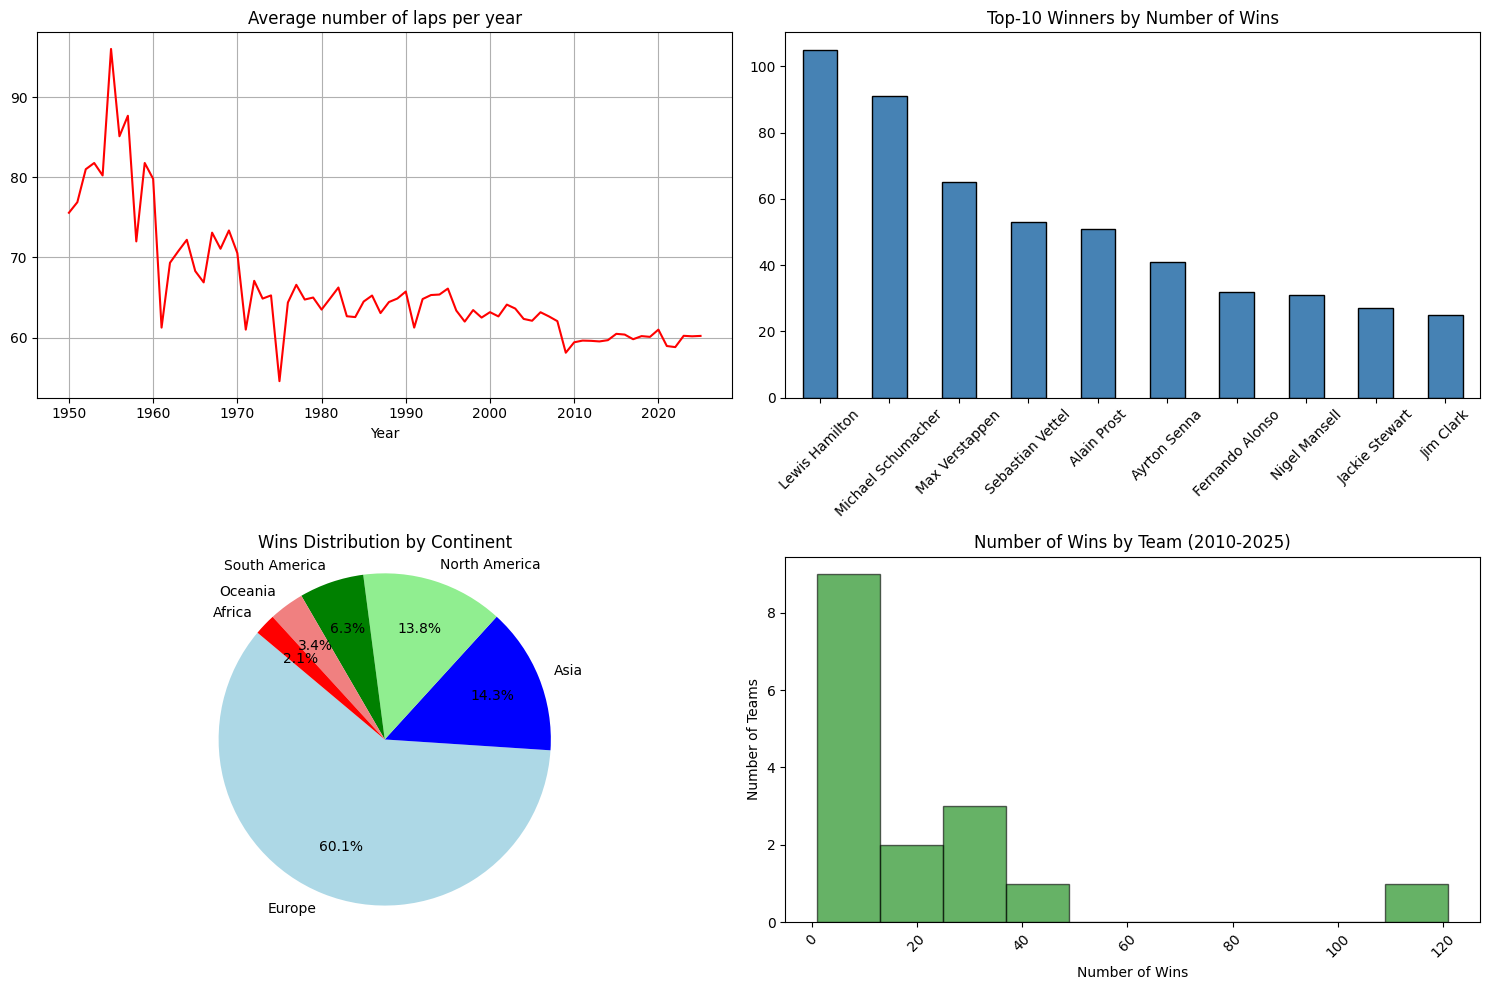

In [159]:
plt.figure(figsize = (15, 10))
plt.subplot(2, 2, 1)
laps_per_year.plot(kind='line', color='red')
plt.title('Average number of laps per year')
plt.xlabel('Year')
# plt.ylabel('Average number of laps')
plt.grid(True) 
plt.tight_layout()

plt.subplot(2, 2, 2)
top_winners.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top-10 Winners by Number of Wins')
plt.xlabel('')
# plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()

plt.subplot(2, 2, 3)
continent_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, pctdistance=0.7, colors=['lightblue', 'blue', 'lightgreen', 'green', 'lightcoral', 'red'])
plt.title('Wins Distribution by Continent')
plt.ylabel('')
plt.axis('equal')
plt.tight_layout()

plt.subplot(2, 2, 4)
count_team.plot(kind='hist', color='green', edgecolor='black', alpha=0.6)
plt.title('Number of Wins by Team (2010-2025)')
plt.xlabel('Number of Wins')
plt.ylabel('Number of Teams')
plt.xticks(rotation=45)
plt.tight_layout()


plt.show()